# __Wearable dataset - predicting the physiological state__

Ilina Durakovska

__Dataset:__ Wearable Device Dataset from Induced Stress and Structured Exercise Sessions \
__Physionet Link:__ [https://physionet.org/content/wearable-device-dataset/1.0.1/](https://physionet.org/content/wearable-device-dataset/1.0.1/) \
__Kaggle (unofficial) Link:__ [https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise](https://www.kaggle.com/datasets/protobioengineering/wearable-device-dataset-during-stress-and-exercise)

In [112]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras import layers, models, callbacks

In [13]:
warnings.filterwarnings("ignore")

---

## __Loading and prepping the data:__

In [32]:
df = pd.read_csv('wearable_dataset_windows_updated.csv')

When making the windows, some subjects had missaligned labels that did not match the protocols that were described. To make sure this does not pollute out data, I'm gonna filter out their sessions just to be safe. 

In [35]:
print(f"In total, there are: {len(df)} windows before filtering.")

In total, there are: 37652 windows before filtering.


In [37]:
MISALIGNED_SESSIONS = {
    ("S03", "AEROBIC"),
    ("S07", "AEROBIC"),
    ("S11", "AEROBIC"),
    ("S06", "ANAEROBIC"),
    ("S16", "ANAEROBIC"),
}

In [41]:
df = df[
    ~df.apply(lambda r: (r["patient_id"], r["session"]) in MISALIGNED_SESSIONS, axis=1)
].reset_index(drop=True)

print(f"Dropped misaligned sessions, {len(df)} windows remain.")

Dropped misaligned sessions, 36320 windows remain.


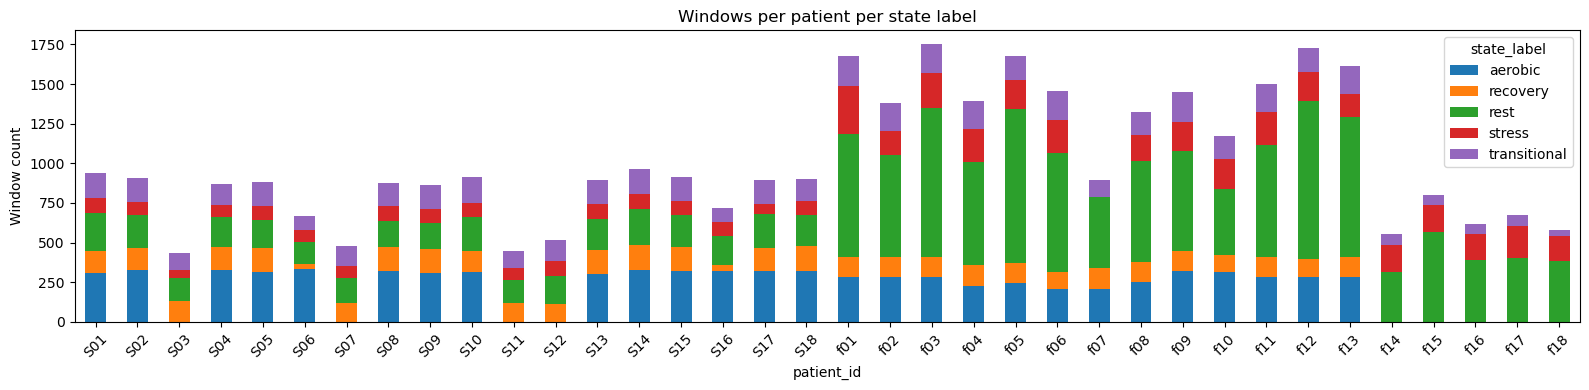

In [47]:
counts = df.groupby(["patient_id", "state_label"]).size().unstack(fill_value=0)
counts.plot(kind="bar", stacked=True, figsize=(16, 4))
plt.title("Windows per patient per state label")
plt.ylabel("Window count")
plt.xticks(rotation=45)
plt.tight_layout()

---

## __Random Forest__

The training and evaluation will be done using the Leave-One-Patient-Out (LOPO) strategy. We train on data from all but one patient, and predict the labels of the last patient. We do this for each patient one by one, then look at their individual and averaged metrics.

In [52]:
EXCLUDE_COLS = {
    "patient_id", "session", "phase", "state_label", "state_label_int",
    "window_index", "t_start_sec", "t_end_sec",
    "hp_quality_flag", "motion_artifact_flag", "tags_misaligned",
}

In [54]:
RF_PARAMS = dict(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

In [81]:
def prepare_data(df):
    clean = df.copy()

    if "state_label" in clean.columns:
        clean = clean[clean["state_label"] != "transitional"]

    if "tags_misaligned" in clean.columns:
        clean = clean[~clean["tags_misaligned"]]

    feature_cols = [c for c in clean.columns if c not in EXCLUDE_COLS]

    clean["hp_sd1/sd2"] = clean["hp_sd1/sd2"].replace([np.inf, -np.inf], np.nan)
    clean["hp_sd1/sd2"] = clean["hp_sd1/sd2"].fillna(clean["hp_sd1/sd2"].max())

    clean = clean.dropna(subset=feature_cols)

    X = clean[feature_cols]
    y = clean["state_label"]
    groups = clean["patient_id"]

    return X, y, groups, feature_cols

In [83]:
def run_one_fold(X, y, groups, test_patient, rf_params=RF_PARAMS):
    """
    Train on everyone except `test_patient`, test on `test_patient`.
    Returns a dict of metrics plus the fitted model and predictions.
    """
    train_mask = groups != test_patient
    test_mask = groups == test_patient

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(X_test) == 0:
        return None

    model = RandomForestClassifier(**rf_params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    result = {
        "patient_id": test_patient,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "y_true": y_test.values,
        "y_pred": y_pred,
        "model": model,
    }
    return result

In [85]:
def run_lopo_cv(df, rf_params=RF_PARAMS, verbose=True):
    """
    Leave-one-patient-out cross-validation over the whole dataframe.
    Returns (fold_results: list[dict], summary_df: pd.DataFrame)
    """
    X, y, groups, feature_cols = prepare_data(df)
    patients = sorted(groups.unique())

    fold_results = []
    for pid in patients:
        res = run_one_fold(X, y, groups, pid, rf_params=rf_params)
        if res is None:
            if verbose:
                print(f"  [{pid}] skipped — no test windows")
            continue
        fold_results.append(res)
        if verbose:
            print(f"  [{pid}] n_train={res['n_train']:>5}  n_test={res['n_test']:>4}  "
                  f"acc={res['accuracy']:.3f}  bal_acc={res['balanced_accuracy']:.3f}  "
                  f"f1_macro={res['f1_macro']:.3f}")

    summary_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("y_true", "y_pred", "model")}
        for r in fold_results
    ])

    return fold_results, summary_df

In [87]:
def summarize_lopo(fold_results, summary_df):
    """
    Print averaged metrics across all folds, plus an overall (pooled)
    classification report and confusion matrix built from every fold's
    held-out predictions concatenated together.
    """
    print("\n=== Per-metric average across patients (mean ± std) ===")
    for metric in ["accuracy", "balanced_accuracy", "f1_macro", "f1_weighted"]:
        vals = summary_df[metric]
        print(f"{metric:>20}: {vals.mean():.3f} ± {vals.std():.3f}")

    all_true = np.concatenate([r["y_true"] for r in fold_results])
    all_pred = np.concatenate([r["y_pred"] for r in fold_results])

    print("\n=== Pooled classification report (all held-out folds combined) ===")
    print(classification_report(all_true, all_pred, zero_division=0))

    labels = sorted(pd.unique(np.concatenate([all_true, all_pred])))
    cm = confusion_matrix(all_true, all_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=labels, columns=labels)
    print("=== Pooled confusion matrix ===")
    print(cm_df)

    return cm_df

In [89]:
fold_results, summary_df = run_lopo_cv(df)

  [S01] n_train=30639  n_test= 783  acc=0.816  bal_acc=0.668  f1_macro=0.647
  [S02] n_train=30668  n_test= 754  acc=0.757  bal_acc=0.632  f1_macro=0.646
  [S03] n_train=31094  n_test= 328  acc=0.692  bal_acc=0.544  f1_macro=0.505
  [S04] n_train=30687  n_test= 735  acc=0.771  bal_acc=0.613  f1_macro=0.593
  [S05] n_train=30691  n_test= 731  acc=0.762  bal_acc=0.636  f1_macro=0.634
  [S06] n_train=30841  n_test= 581  acc=0.704  bal_acc=0.454  f1_macro=0.413
  [S07] n_train=31070  n_test= 352  acc=0.761  bal_acc=0.686  f1_macro=0.711
  [S08] n_train=30689  n_test= 733  acc=0.754  bal_acc=0.623  f1_macro=0.608
  [S09] n_train=30709  n_test= 713  acc=0.724  bal_acc=0.653  f1_macro=0.645
  [S10] n_train=30670  n_test= 752  acc=0.641  bal_acc=0.583  f1_macro=0.553
  [S11] n_train=31079  n_test= 343  acc=0.641  bal_acc=0.550  f1_macro=0.504
  [S12] n_train=31039  n_test= 383  acc=0.731  bal_acc=0.702  f1_macro=0.711
  [S13] n_train=30676  n_test= 746  acc=0.732  bal_acc=0.605  f1_macro=0.604

In [92]:
cm_df = summarize_lopo(fold_results, summary_df)


=== Per-metric average across patients (mean ± std) ===
            accuracy: 0.699 ± 0.100
   balanced_accuracy: 0.576 ± 0.104
            f1_macro: 0.552 ± 0.124
         f1_weighted: 0.657 ± 0.109

=== Pooled classification report (all held-out folds combined) ===
              precision    recall  f1-score   support

     aerobic       0.83      0.87      0.85      7959
    recovery       0.71      0.57      0.63      3905
        rest       0.67      0.81      0.73     14829
      stress       0.35      0.15      0.21      4729

    accuracy                           0.69     31422
   macro avg       0.64      0.60      0.60     31422
weighted avg       0.67      0.69      0.67     31422

=== Pooled confusion matrix ===
          aerobic  recovery   rest  stress
aerobic      6924       255    780       0
recovery      567      2214   1124       0
rest          897       653  12003    1276
stress          0         0   4038     691


---

## __SVM__

In [100]:
SVM_PARAMS = dict(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=42,
)

In [102]:
def run_one_fold_svm(X, y, groups, test_patient, svm_params=SVM_PARAMS):
    """
    Same idea as run_one_fold, but scales features (fit on train only)
    before handing them to the SVM.
    """
    train_mask = groups != test_patient
    test_mask = groups == test_patient

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(X_test) == 0:
        return None

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = SVC(**svm_params)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    result = {
        "patient_id": test_patient,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "y_true": y_test.values,
        "y_pred": y_pred,
        "model": model,
        "scaler": scaler,
    }
    return result

In [104]:
def run_lopo_cv_svm(df, svm_params=SVM_PARAMS, verbose=True):
    X, y, groups, feature_cols = prepare_data(df)
    patients = sorted(groups.unique())

    fold_results = []
    for pid in patients:
        res = run_one_fold_svm(X, y, groups, pid, svm_params=svm_params)
        if res is None:
            if verbose:
                print(f"  [{pid}] skipped — no test windows")
            continue
        fold_results.append(res)
        if verbose:
            print(f"  [{pid}] n_train={res['n_train']:>5}  n_test={res['n_test']:>4}  "
                  f"acc={res['accuracy']:.3f}  bal_acc={res['balanced_accuracy']:.3f}  "
                  f"f1_macro={res['f1_macro']:.3f}")

    summary_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("y_true", "y_pred", "model", "scaler")}
        for r in fold_results
    ])

    return fold_results, summary_df

In [106]:
fold_results_svm, summary_df_svm = run_lopo_cv_svm(df)

  [S01] n_train=30639  n_test= 783  acc=0.788  bal_acc=0.797  f1_macro=0.747
  [S02] n_train=30668  n_test= 754  acc=0.586  bal_acc=0.548  f1_macro=0.421
  [S03] n_train=31094  n_test= 328  acc=0.607  bal_acc=0.639  f1_macro=0.443
  [S04] n_train=30687  n_test= 735  acc=0.699  bal_acc=0.697  f1_macro=0.609
  [S05] n_train=30691  n_test= 731  acc=0.584  bal_acc=0.517  f1_macro=0.529
  [S06] n_train=30841  n_test= 581  acc=0.716  bal_acc=0.507  f1_macro=0.409
  [S07] n_train=31070  n_test= 352  acc=0.653  bal_acc=0.734  f1_macro=0.657
  [S08] n_train=30689  n_test= 733  acc=0.752  bal_acc=0.679  f1_macro=0.666
  [S09] n_train=30709  n_test= 713  acc=0.669  bal_acc=0.652  f1_macro=0.553
  [S10] n_train=30670  n_test= 752  acc=0.727  bal_acc=0.628  f1_macro=0.618
  [S11] n_train=31079  n_test= 343  acc=0.545  bal_acc=0.617  f1_macro=0.494
  [S12] n_train=31039  n_test= 383  acc=0.601  bal_acc=0.668  f1_macro=0.466
  [S13] n_train=30676  n_test= 746  acc=0.701  bal_acc=0.700  f1_macro=0.619

In [107]:
cm_df_svm = summarize_lopo(fold_results_svm, summary_df_svm)


=== Per-metric average across patients (mean ± std) ===
            accuracy: 0.571 ± 0.134
   balanced_accuracy: 0.631 ± 0.104
            f1_macro: 0.508 ± 0.121
         f1_weighted: 0.541 ± 0.144

=== Pooled classification report (all held-out folds combined) ===
              precision    recall  f1-score   support

     aerobic       0.76      0.82      0.79      7959
    recovery       0.50      0.68      0.58      3905
        rest       0.74      0.28      0.40     14829
      stress       0.34      0.88      0.49      4729

    accuracy                           0.55     31422
   macro avg       0.59      0.66      0.57     31422
weighted avg       0.66      0.55      0.54     31422

=== Pooled confusion matrix ===
          aerobic  recovery  rest  stress
aerobic      6523      1036   400       0
recovery      764      2651   473      17
rest         1342      1530  4106    7851
stress          0        33   558    4138


---

## __LSTM__

In [114]:
SEQ_LEN = 10       # number of consecutive windows per sequence (10 windows * 5s stride ≈ 50s of extra context)
SEQ_STRIDE = 5      # step between sequence start points, in windows

In [116]:
LSTM_PARAMS = dict(
    units=64,
    dropout=0.3,
    epochs=30,
    batch_size=64,
    patience=5,
)

In [118]:
def prepare_clean_df(df):
    clean = df.copy()

    if "state_label" in clean.columns:
        clean = clean[clean["state_label"] != "transitional"]
    if "tags_misaligned" in clean.columns:
        clean = clean[~clean["tags_misaligned"]]

    feature_cols = [c for c in clean.columns if c not in EXCLUDE_COLS]
    clean[feature_cols] = clean[feature_cols].replace([np.inf, -np.inf], np.nan)
    clean = clean.dropna(subset=feature_cols)

    return clean, feature_cols

In [120]:
def build_sequences(clean_df, feature_cols, seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE):
    """
    Groups by (patient_id, session), sorts by time, and slides a length-`seq_len`
    window over the feature rows. Each sequence is labeled with the state_label
    of its *last* row (i.e. "predict the current state given the recent past").
    """
    X_list, y_list, pid_list = [], [], []

    for (pid, session), group in clean_df.groupby(["patient_id", "session"]):
        group = group.sort_values("t_start_sec")
        feats = group[feature_cols].values
        labels = group["state_label"].values

        n = len(group)
        if n < seq_len:
            continue

        for start in range(0, n - seq_len + 1, seq_stride):
            end = start + seq_len
            X_list.append(feats[start:end])
            y_list.append(labels[end - 1])
            pid_list.append(pid)

    X = np.array(X_list)                # (n_sequences, seq_len, n_features)
    y = np.array(y_list)
    groups = np.array(pid_list)
    return X, y, groups

In [122]:
def build_lstm_model(seq_len, n_features, n_classes, params=LSTM_PARAMS):
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.LSTM(params["units"], return_sequences=False),
        layers.Dropout(params["dropout"]),
        layers.Dense(32, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [124]:
def run_one_fold_lstm(X, y, groups, test_patient, label_encoder, params=LSTM_PARAMS):
    train_mask = groups != test_patient
    test_mask = groups == test_patient

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    if len(X_test) == 0:
        return None

    # scale: fit on train only, flatten to 2D for the scaler then reshape back
    seq_len, n_features = X.shape[1], X.shape[2]
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
    X_test_scaled = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

    y_train_enc = label_encoder.transform(y_train)
    y_test_enc = label_encoder.transform(y_test)

    model = build_lstm_model(seq_len, n_features, len(label_encoder.classes_), params)

    es = callbacks.EarlyStopping(monitor="loss", patience=params["patience"], restore_best_weights=True)
    model.fit(
        X_train_scaled, y_train_enc,
        epochs=params["epochs"], batch_size=params["batch_size"],
        callbacks=[es], verbose=0,
    )

    y_pred_enc = model.predict(X_test_scaled, verbose=0).argmax(axis=1)
    y_pred = label_encoder.inverse_transform(y_pred_enc)

    result = {
        "patient_id": test_patient,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
        "y_true": y_test,
        "y_pred": y_pred,
        "model": model,
    }
    return result

In [126]:
def run_lopo_cv_lstm(df, seq_len=SEQ_LEN, seq_stride=SEQ_STRIDE, params=LSTM_PARAMS, verbose=True):
    clean_df, feature_cols = prepare_clean_df(df)
    X, y, groups = build_sequences(clean_df, feature_cols, seq_len, seq_stride)

    label_encoder = LabelEncoder()
    label_encoder.fit(y)   # fit on all classes up front so encoding is consistent across folds

    patients = sorted(np.unique(groups))
    fold_results = []

    for pid in patients:
        res = run_one_fold_lstm(X, y, groups, pid, label_encoder, params=params)
        if res is None:
            if verbose:
                print(f"  [{pid}] skipped — no test sequences")
            continue
        fold_results.append(res)
        if verbose:
            print(f"  [{pid}] n_train={res['n_train']:>5}  n_test={res['n_test']:>4}  "
                  f"acc={res['accuracy']:.3f}  bal_acc={res['balanced_accuracy']:.3f}  "
                  f"f1_macro={res['f1_macro']:.3f}")

    summary_df = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ("y_true", "y_pred", "model")}
        for r in fold_results
    ])

    return fold_results, summary_df

In [128]:
fold_results_lstm, summary_df_lstm = run_lopo_cv_lstm(df)

  [S01] n_train= 6006  n_test= 153  acc=0.778  bal_acc=0.639  f1_macro=0.623
  [S02] n_train= 6012  n_test= 147  acc=0.741  bal_acc=0.643  f1_macro=0.609
  [S03] n_train= 6097  n_test=  62  acc=0.629  bal_acc=0.581  f1_macro=0.455
  [S04] n_train= 6017  n_test= 142  acc=0.810  bal_acc=0.674  f1_macro=0.671
  [S05] n_train= 6017  n_test= 142  acc=0.620  bal_acc=0.528  f1_macro=0.518
  [S06] n_train= 6045  n_test= 114  acc=0.728  bal_acc=0.441  f1_macro=0.430
  [S07] n_train= 6092  n_test=  67  acc=0.552  bal_acc=0.541  f1_macro=0.548
  [S08] n_train= 6016  n_test= 143  acc=0.727  bal_acc=0.626  f1_macro=0.621
  [S09] n_train= 6021  n_test= 138  acc=0.688  bal_acc=0.627  f1_macro=0.618
  [S10] n_train= 6013  n_test= 146  acc=0.630  bal_acc=0.572  f1_macro=0.498
  [S11] n_train= 6093  n_test=  66  acc=0.682  bal_acc=0.613  f1_macro=0.608
  [S12] n_train= 6085  n_test=  74  acc=0.500  bal_acc=0.392  f1_macro=0.267
  [S13] n_train= 6014  n_test= 145  acc=0.600  bal_acc=0.587  f1_macro=0.590

In [129]:
cm_df_lstm = summarize_lopo(fold_results_lstm, summary_df_lstm)


=== Per-metric average across patients (mean ± std) ===
            accuracy: 0.657 ± 0.090
   balanced_accuracy: 0.565 ± 0.096
            f1_macro: 0.534 ± 0.105
         f1_weighted: 0.630 ± 0.091

=== Pooled classification report (all held-out folds combined) ===
              precision    recall  f1-score   support

     aerobic       0.79      0.78      0.79      1571
    recovery       0.59      0.61      0.60       784
        rest       0.66      0.74      0.70      2869
      stress       0.36      0.21      0.27       935

    accuracy                           0.66      6159
   macro avg       0.60      0.59      0.59      6159
weighted avg       0.64      0.66      0.64      6159

=== Pooled confusion matrix ===
          aerobic  recovery  rest  stress
aerobic      1229       155   187       0
recovery      119       478   187       0
rest          208       167  2135     359
stress          0         5   730     200
